# <font style="color:blue">Project 1 - Part 2: Train an Image Classifier From Scratch</font>
As discussed in the previous notebook, the steps for training Neural Networks are:

- Step 1 - Understand your problem
- Step 2A - Get the data
- Step 2B - Explore and understand your data
- Step 2C - Create a sample data from the dataset
- Step 3 - Data preparation
- Step 4 - Train a simple model on sample data and check the pipeline before proceeding to train the full network
- Step 5 - Train on full Data
- Step 6 - Improve your model
- Step 7 - Generate Submission file


Follow Steps 1-4 exactly as you did in the previous notebook. Here, you will implement Steps 5, 6 & 7 from scratch.


There are **70 points** for this notebook. <font style="color:red">The sections which carry marks are in Red.</font>


**To achieve full marks in this notebook design a model that achieves `>=85%` Public Test accuracy on the given dataset.**

**<font style="color:red">Build your own model from scratch, and do not use any pre-trained models/weights.</font>**


#### Points Distribution - Maximum Points: 70


<div align="center">
    <table>
        <tr><td><h3>Number</h3></td> <td><h3>Section</h3></td> <td><h3>Points</h3></td> </tr>
        <tr><td><h3>1</h3></td> <td><h3>Configurations</h3></td> <td><h3>5</h3></td> </tr>
        <tr><td><h3>2</h3></td> <td><h3>Define Model</h3></td> <td><h3>10</h3></td> </tr>
        <tr><td><h3>3</h3></td> <td><h3>Display Confusion Matrix</h3></td><td><h3>5</h3></td> </tr>
        <tr><td><h3>4</h3></td> <td><h3>Generate Submission File</h3></td><td><h3>10</h3></td> </tr>
        <tr><td><h3>5</h3></td> <td><h3>Kaggle Submission Score</h3></td> <td><h3>40</h3></td> </tr>
    </table>
</div>


**Kaggle Submission Score Points Distribution**

<div align="center">
    <table>
        <tr><td><h3>Number</h3></td> <td><h3>Public Test Set Accuracy</h3></td> <td><h3>Points</h3></td> </tr>
        <tr><td><h3>1</h3></td> <td><h3>>= 85%</h3></td> <td><h3>40</h3></td> </tr>
        <tr><td><h3>2</h3></td> <td><h3>84%</h3></td> <td><h3>38</h3></td> </tr>
        <tr><td><h3>3</h3></td> <td><h3>83%</h3></td> <td><h3>36</h3></td> </tr>
        <tr><td><h3>4</h3></td> <td><h3>82%</h3></td><td><h3>34</h3></td> </tr>
        <tr><td><h3>5</h3></td> <td><h3>81%</h3></td> <td><h3>32</h3></td> </tr>
        <tr><td><h3>6</h3></td> <td><h3>80%</h3></td> <td><h3>30</h3></td> </tr>
        <tr><td><h3>7</h3></td> <td><h3>< 80%</h3></td> <td><h3>0</h3></td> </tr>
    </table>
</div>

**Note: Percentages will be rounded off to the nearest integer.**

**After completing the project, upload and submit the notebook to the lab for feedback.**

**<font style="color:red">You need to achieve atleast 80% accuracy on the Public test leaderboard to successfully complete this project.</font>**

# <font style="color:blue">Step 1: Understand Your problem </font><a name="step1"></a>
Already covered in the previous notebook.

## <font style="color:blue">3.1. Import Libraries </font>

In [1]:
import os
import time
from dataclasses import dataclass
from typing import List, Union, Tuple

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim import lr_scheduler
from torch.utils.tensorboard import SummaryWriter



2025-12-06 05:39:30.789440: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764999570.810312    5135 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764999570.816752    5135 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
from torchvision import datasets, transforms

from torchmetrics import MeanMetric
from torchmetrics.classification import MulticlassAccuracy

from torch.utils.data import DataLoader


# Text formatting
bold = "\033[1m"
end = "\033[0m"

plt.style.use('ggplot')
block_plot=False

%matplotlib inline

glocal_run = False
gpredict_only = False

In [3]:
if not glocal_run:
    print(os.path.abspath('.'))
    os.path.isdir('/kaggle/input/open-cv-py-torch-project-2-classification-round-2/')
    print(os.path.isdir('/kaggle/input/open-cv-py-torch-project-1-classification-round-2/dataset/Train'))


/kaggle/working
True


In [4]:
#local data folders
if glocal_run:
    train_data = datasets.ImageFolder("../data/animal-data/dataset/Train")
    validation_data = datasets.ImageFolder("../data/animal-data/dataset/Valid")
else:
    # Kaggle data folders
    train_data = datasets.ImageFolder('/kaggle/input/open-cv-py-torch-project-1-classification-round-2/dataset/Train')
    validation_data = datasets.ImageFolder('/kaggle/input/open-cv-py-torch-project-1-classification-round-2/dataset/Valid')

subset_size = 0.05  # Use 5% of data for quick testing

train_subset = torch.utils.data.Subset(train_data,np.arange(0,len(train_data),1./subset_size))
validation_subset = torch.utils.data.Subset(validation_data,np.arange(0,len(validation_data),1./subset_size))

train_subset_loader = torch.utils.data.DataLoader(train_subset,
                                         batch_size=8,
                                         num_workers=1,
                                         shuffle=False)
validation_subset_loader = torch.utils.data.DataLoader(validation_subset,
                                         batch_size=8,
                                         num_workers=1,
                                         shuffle=False)

print("Train Subset Size: {}".format(len(train_subset_loader.dataset)))
print("Validation Subset Size: {}".format(len(validation_subset_loader.dataset)))



Train Subset Size: 105
Validation Subset Size: 15


In [5]:
def subset_data_loader(data_root, transform, batch_size=8, shuffle=False, num_workers=2, subset_size=0.05):
    dataset = datasets.ImageFolder(root=data_root, transform=transform)

    data_subset = torch.utils.data.Subset(dataset,np.arange(0,len(dataset),1./subset_size).astype(int))

    loader = torch.utils.data.DataLoader(data_subset,
                                         batch_size=batch_size,
                                         num_workers=num_workers,
                                         shuffle=shuffle)

    return loader

### <font style="color:green">3.2.1. Compulsary Preprocessing Transforms</font>

In [6]:
def image_preprocess_transforms(img_size):
    preprocess = transforms.Compose(
        [
            transforms.Resize(img_size),
            transforms.ToTensor(),
        ]
    )

    return preprocess

### <font style="color:green">3.2.2. Common Image Transforms</font>

In [7]:
def image_common_transforms(img_size=(224, 224), mean=(0.4611, 0.4359, 0.3905), std=(0.2193, 0.2150, 0.2109)):
    preprocess = image_preprocess_transforms(img_size)

    common_transforms = transforms.Compose(
        [
            preprocess,
            transforms.Normalize(mean, std),
        ]
    )

    return common_transforms

### <font style="color:green">3.2.3. Mean and STD</font>

Function for Calculating Mean and Variance.

In [8]:
def get_mean_std(data_root, img_size=(224, 224), num_workers=4):
    transform = image_preprocess_transforms(img_size=img_size)

    loader = data_loader(data_root, transform)

    batch_mean = torch.zeros(3)
    batch_mean_sqrd = torch.zeros(3)

    for batch_data, _ in loader:
        batch_mean += batch_data.mean(dim=(0, 2, 3))  # E[batch_i]
        batch_mean_sqrd += (batch_data**2).mean(dim=(0, 2, 3))  #  E[batch_i**2]

    # E[dataset] = E[E[batch_1], E[batch_2], ...]
    mean = batch_mean / len(loader)

    # var[X] = E[X**2] - E[X]**2

    # E[X**2] = E[E[batch_1**2], E[batch_2**2], ...]
    # E[X]**2 = E[E[batch_1], E[batch_2], ...] ** 2

    var = (batch_mean_sqrd / len(loader)) - (mean**2)

    std = var**0.5
    print("mean: {}, std: {}".format(mean, std))

    return mean, std

## <font style="color:blue">3.3. Data Loaders </font>

### <font style="color:green">3.3.1. Data Loader for Full Data</font>
Data loader for generating batches of data to be used by the training routine

In [9]:
def data_loader(data_root, transform, batch_size=16, shuffle=False, num_workers=2):
    dataset = datasets.ImageFolder(root=data_root, transform=transform)

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=shuffle,
    )

    return loader

## <font style="color:green">3.4. Prepare Data</font>
The main function which uses all the above functions to generate the train and valid dataloaders.


In [10]:
def get_data(batch_size, data_root, img_size=(224, 224), num_workers=4, data_augmentation=False):
    #     YOUR CODE HERE
    # train_data_path = os.path.join(data_root, 'training')
    train_data_path = os.path.join(data_root, 'Train')

    mean, std = get_mean_std(data_root=train_data_path, num_workers=num_workers)

    common_transforms = image_common_transforms(img_size, mean, std)


    # if data_augmentation is true
    # data augmentation implementation
    if data_augmentation:
        # data augmentation is not implemented
        # train_transforms = data_augmentation_preprocess(mean, std)
        train_transforms = common_transforms

    # else do common transforms
    else:
        train_transforms = common_transforms

    train_transforms = transforms.Compose([
        transforms.RandomResizedCrop(img_size),          # random crop + resize
        transforms.RandomHorizontalFlip(),          # flip horizontally
        transforms.ColorJitter(brightness=0.2,
                            contrast=0.2,
                            saturation=0.2,
                            hue=0.1),           # color variations
        transforms.RandomRotation(15),              # small rotations
        transforms.ToTensor(),
        transforms.Normalize(mean,std)
    ])

    val_transforms = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

#ENABLE THIS WHEN ACTUAL TRAINING
    # train dataloader
    dataset = datasets.ImageFolder(root=train_data_path, transform=train_transforms)
    train_loader = DataLoader(dataset=dataset,batch_size=batch_size,num_workers=num_workers,shuffle=True)


    # test dataloader
    test_data_path = os.path.join(data_root, 'Valid')
    # dataset = datasets.ImageFolder(root=test_data_path, transform=train_transforms)
    dataset = datasets.ImageFolder(root=test_data_path, transform=val_transforms)
    test_loader = DataLoader(dataset=dataset,batch_size=batch_size,num_workers=num_workers,shuffle=False)

#DISABLE THIS WHEN ACTUAL TRAINING
    # train dataloader

    # train_loader = subset_data_loader(train_data_path,
    #                            train_transforms,
    #                            batch_size=batch_size,
    #                            shuffle=True,
    #                            num_workers=num_workers)

    # # test dataloader

    # # test_data_path = os.path.join(data_root, 'validation')
    # test_data_path = os.path.join(data_root, 'Valid')

    # test_loader = subset_data_loader(test_data_path,
    #                           train_transforms,
    #                           batch_size=batch_size,
    #                           shuffle=False,
    #                           num_workers=num_workers)

    return train_loader, test_loader

# <font style="color:blue">Step 4: Train Your Model</font><a name="step4"></a>

Now, create the training pipeline, and train your model on the full data.

## <font style="color:red">4.1. Configurations [5 Points]</font>

To achieve good results, change the parameters given in these configurations.

### <font style="color:green">4.1.1. System Configuration</font>

Fix the seed (e.g., `21`) to get a reproducible result. 

In [11]:
@dataclass
class SystemConfig:
    """
    Describes the common system setting needed for reproducible training
    """

    seed: int = 21  # Seed number to set the state of all random number generators
    cudnn_benchmark_enabled: bool = True  # Enable CuDNN benchmark for the sake of performance
    cudnn_deterministic: bool = True  # Make cudnn deterministic (reproducible training)

### <font style="color:green">4.1.2. Training Configuration</font>

In [12]:
@dataclass
class TrainingConfig:
    """
    Describes configuration of the training process
    """

    num_classes: int = 3
    batch_size: int = 32
    img_size: Tuple = (224, 224)
    epochs_count: int = 200
    init_learning_rate: float = 1e-3  # Initial learning rate
    # Predict only flag
    if gpredict_only:
        predict_only: bool = True
    else:
        predict_only: bool = False

    # run on local machine
    if glocal_run:
        local_run: bool = True
    else:
        local_run: bool = False


    if local_run:
        data_root: str = "../data/animal-data/dataset"
    else:
        data_root: str = "/kaggle/input/open-cv-py-torch-project-1-classification-round-2/dataset"
    num_workers: int = 4
    device: str = "cuda"

    # For tensorboard logging and saving checkpoints
    save_model_name: str = "cat_dog_panda_classifier.pt"
    # root_log_dir: str = os.path.join("kaggle", "working", "Logs_Checkpoints", "Model_logs")
    # root_checkpoint_dir: str = os.path.join("kaggle", "working", "Logs_Checkpoints", "Model_checkpoints")
    root_log_dir: str = os.path.join("Logs_Checkpoints", "Model_logs")
    root_checkpoint_dir: str = os.path.join("Logs_Checkpoints", "Model_checkpoints")

    # Current log and checkpoint directory.
    log_dir: str = "version_0"
    checkpoint_dir: str = "version_0"



    # overwrite values when GPU is not present
    if not torch.cuda.is_available():
        device: str = "cpu"
        num_workers: int = 2
        batch_size: int = 2
        epochs_count: int = 5

### <font style="color:green">4.1.3. System Setup</font>

In [13]:
def setup_system(system_config: SystemConfig) -> None:
    torch.manual_seed(system_config.seed)
    if torch.cuda.is_available():
        torch.backends.cudnn_benchmark_enabled = system_config.cudnn_benchmark_enabled
        torch.backends.cudnn.deterministic = system_config.cudnn_deterministic

## <font style="color:blue">4.2. Training Function</font>

In the next code cell, we are going to define the training function, which is a crucial step in our deep learning pipeline. This function will handle the processes involved in training, including feeding data to the model, adjusting weights, and optimizing performance.

You are already familiar with the training function. No changes needed here.

In [14]:
def freeze_until_block4(model):
    """
    Freeze all params except block5, block6, and _head.
    """
    for name, p in model.named_parameters():
        if name.startswith('block5') or name.startswith('block6') or name.startswith('_head'):
            p.requires_grad = True
        else:
            p.requires_grad = False

def make_finetune_optimizer(model, lr_head=1e-3, lr_body=5e-4, weight_decay=1e-4):
    head_params = [p for n, p in model.named_parameters() if p.requires_grad and '_head' in n]
    body_params = [p for n, p in model.named_parameters() if p.requires_grad and ('block5' in n or 'block6' in n)]
    optim_groups = []
    if body_params:
        optim_groups.append({'params': body_params, 'lr': lr_body})
    if head_params:
        optim_groups.append({'params': head_params, 'lr': lr_head})
    optimizer = torch.optim.AdamW(optim_groups, weight_decay=weight_decay)
    return optimizer


In [15]:
def train(
    train_config: TrainingConfig,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    train_loader: torch.utils.data.DataLoader,
    epoch_idx: int,
    total_epochs: int,
) -> Tuple[float, float]:

    # Change model in training mode.
    model.train()

    acc_metric = MulticlassAccuracy(num_classes=train_config.num_classes, average="micro")
    mean_metric = MeanMetric()

    device = train_config.device

    status = f"Train:\t{bold}Epoch: {epoch_idx}/{total_epochs}{end}"

    prog_bar = tqdm(train_loader, bar_format="{l_bar}{bar:10}{r_bar}{bar:-10b}")

    prog_bar.set_description(status)

    for data, target in prog_bar:
        # Send data and target to appropriate device.
        data, target = data.to(device), target.to(device)

        # Reset parameters gradient to zero.
        optimizer.zero_grad()

        # Forward pass to the model.
        output = model(data)
        # trying give different weights to different classes (high for cats and dogs, low for panda)
        weights = torch.tensor([2.5, 2, 0.8], dtype=torch.float)
        # Cross Entropy loss
        # loss = F.cross_entropy(output, target)
        loss = F.cross_entropy(output, target, weight=weights.to(device))

        # Find gradients w.r.t training parameters.
        loss.backward()

        # Update parameters using gradients.
        optimizer.step()

        # Batch Loss.
        mean_metric(loss.item(), weight=data.shape[0])

        # # Get probability score using softmax.
        # prob = F.softmax(output, dim=1)

        # Get the index of the max probability.
        pred_idx = output.detach().argmax(dim=1)

        # Batch accuracy.
        acc_metric(pred_idx.cpu(), target.cpu())

        # Update progress bar description.
        step_status = status + f" Train Loss: {mean_metric.compute():.4f}, Train Acc: {acc_metric.compute():.4f}"
        prog_bar.set_description(step_status)

    epoch_loss = mean_metric.compute()
    epoch_acc = acc_metric.compute()

    prog_bar.close()

    return epoch_loss, epoch_acc

## <font style="color:blue">4.3. Validation Function</font>

In the upcoming code cell, we will create the validation function. This function is essential for assessing the performance of our model on unseen data, ensuring its effectiveness and accuracy.

In [16]:
def validate(
    train_config: TrainingConfig,
    model: nn.Module,
    valid_loader: torch.utils.data.DataLoader,
    epoch_idx: int,
    total_epochs: int
) -> Tuple[float, float]:

    # Change model in evaluation mode.
    model.eval()

    acc_metric = MulticlassAccuracy(num_classes=train_config.num_classes, average="micro")
    mean_metric = MeanMetric()

    device = train_config.device

    status = f"Valid:\t{bold}Epoch: {epoch_idx}/{total_epochs}{end}"

    prog_bar = tqdm(valid_loader, bar_format="{l_bar}{bar:10}{r_bar}{bar:-10b}")

    prog_bar.set_description(status)

    for data, target in prog_bar:
        # Send data and target to appropriate device.
        data, target = data.to(device), target.to(device)

        # Get the model's predicted logits.
        with torch.no_grad():
            output = model(data)

        # Compute the CE-Loss.
        valid_loss = F.cross_entropy(output, target).item()

        # Batch validation loss.
        mean_metric(valid_loss, weight=data.shape[0])

        # # Convert model's logits to probability scores.
        # prob = F.softmax(output, dim=1)

        # Get the index of the max probability.
        pred_idx = output.detach().argmax(dim=1)

        # Batch accuracy.
        acc_metric(pred_idx.cpu(), target.cpu())

        # Update progress bar description.
        step_status = status + f" Valid Loss: {mean_metric.compute():.4f}, Valid Acc: {acc_metric.compute():.4f}"
        prog_bar.set_description(step_status)

    valid_loss = mean_metric.compute()
    valid_acc = acc_metric.compute()

    prog_bar.close()

    return valid_loss, valid_acc

## <font style="color:blue">4.4. Save & Load Model</font>

The following two code cells are dedicated to essential functions in deep learning model management:

1. **Saving the Model Function**: This function is crucial for preserving the trained model state, allowing us to store the learned parameters for future use or further analysis.

2. **Loading the Model Function**: This function is designed to retrieve and load a previously saved model. It's vital for resuming training, making predictions, or conducting evaluations without having to retrain the model from scratch.


In [17]:
def save_model(model, device, model_dir="models", model_file_name="cat_dog_panda_classifier.pt"):
    if not os.path.exists(model_dir):
        os.makedirs(model_dir)

    model_path = os.path.join(model_dir, model_file_name)

    # Make sure you transfer the model to cpu.
    if device == "cuda":
        model.to("cpu")

    # Save the 'state_dict'
    torch.save(model.state_dict(), model_path)

    if device == "cuda":
        model.to("cuda")

    return

In [18]:
def load_model(model, model_dir="models", model_file_name="cat_dog_panda_classifier.pt", device=torch.device("cpu")):
    model_path = os.path.join(model_dir, model_file_name)

    # Load model parameters by using 'load_state_dict'.
    model.load_state_dict(torch.load(model_path, map_location=device))

    return model

## <font style="color:blue">4.5. Logging Setup</font>

This function will be initializing directories so that they save tensorboard and model checkpoints for different training versions.


In [19]:
def setup_log_directory(training_config=TrainingConfig()):
    """Tensorboard Log and Model checkpoint directory Setup"""

    if os.path.isdir(training_config.root_log_dir):
        # Get all folders numbers in the root_log_dir.
        folder_numbers = [int(folder.replace("version_", "")) for folder in os.listdir(training_config.root_log_dir)]

        # Find the latest version number present in the log_dir
        last_version_number = max(folder_numbers)
        if training_config.predict_only:
            version_name = f"version_{last_version_number}"
        else:
            # New version name
            version_name = f"version_{last_version_number + 1}"

    else:
        version_name = training_config.log_dir

    # Update the training config default directory.
    training_config.log_dir = os.path.join(training_config.root_log_dir, version_name)
    training_config.checkpoint_dir = os.path.join(training_config.root_checkpoint_dir, version_name)

    if not training_config.predict_only:
    # Create new directory for saving new experiment version.
        os.makedirs(training_config.log_dir, exist_ok=True)
        os.makedirs(training_config.checkpoint_dir, exist_ok=True)

        print(f"Logging at: {training_config.log_dir}")
        print(f"Model Checkpoint at: {training_config.checkpoint_dir}")
    else:
        print(f"Predicting using model from: {training_config.checkpoint_dir}")


    return training_config, version_name

## <font style="color:blue">4.6. Plot Loss and Accuracy</font>

The next code cell will focus on developing a function for plotting loss and accuracy graphs. This function is instrumental in visualizing the performance of the deep learning model throughout the training process, providing insights into its learning behavior by displaying trends in loss reduction and accuracy improvement over epochs.


In [20]:
def plot_loss_accuracy(
    train_loss,
    val_loss,
    train_acc,
    val_acc,
    colors,
    loss_legend_loc="upper center",
    acc_legend_loc="upper left",
    fig_size=(20, 10),
    sub_plot1=(1, 2, 1),
    sub_plot2=(1, 2, 2),
):
    plt.rcParams["figure.figsize"] = fig_size
    fig = plt.figure()
    plt.subplot(sub_plot1[0], sub_plot1[1], sub_plot1[2])

    for i in range(len(train_loss)):
        x_train = range(len(train_loss[i]))
        x_val = range(len(val_loss[i]))

        min_train_loss = min(train_loss[i])
        min_val_loss = min(val_loss[i])

        plt.plot(x_train, train_loss[i], linestyle="-", color=f"tab:{colors[i]}", label=f"TRAIN LOSS ({min_train_loss:.4})")
        plt.plot(x_val, val_loss[i], linestyle="--", color=f"tab:{colors[i]}", label=f"VALID LOSS ({min_val_loss:.4})")


    plt.xlabel("epoch no.")
    plt.ylabel("loss")
    plt.legend(loc=loss_legend_loc)
    plt.title("Training and Validation Loss")
    plt.subplot(sub_plot2[0], sub_plot2[1], sub_plot2[2])

    for i in range(len(train_acc)):
        x_train = range(len(train_acc[i]))
        x_val = range(len(val_acc[i]))

        max_train_acc = max(train_acc[i])
        max_val_acc = max(val_acc[i])

        plt.plot(
            x_train,
            train_acc[i],
            linestyle="-",
            color=f"tab:{colors[i]}",
            label=f"TRAIN ACC ({max_train_acc:.4})",
        )

        plt.plot(
            x_val,
            val_acc[i],
            linestyle="--",
            color=f"tab:{colors[i]}",
            label=f"VALID ACC ({max_val_acc:.4})",
        )


    plt.xlabel("epoch no.")
    plt.ylabel("accuracy")
    plt.legend(loc=acc_legend_loc)
    plt.title("Training and Validation Accuracy")
    fig.savefig("sample_loss_acc_plot.png")
    plt.show()

    return

## <font style="color:blue">4.7. Main Function for Training</font>

In this function, we integrate all the various functions we've previously defined, creating a cohesive and streamlined workflow.

In [21]:
from sklearn.metrics import classification_report

def epoch_eval(model, loader, device, class_names=None):
    model.eval()
    preds, targs = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            preds.append(out.argmax(dim=1).cpu())
            targs.append(y)
    preds = torch.cat(preds).numpy()
    targs = torch.cat(targs).numpy()
    print(classification_report(targs, preds, target_names=class_names, digits=4))


In [22]:
def main(model, summary_writer, scheduler=None, system_config=SystemConfig(), training_config=TrainingConfig(), data_augmentation=True):

    # Setup system configuration.
    setup_system(system_config)

    # Initialize data loader
    train_loader, valid_loader = get_data(
        batch_size=training_config.batch_size,
        data_root=training_config.data_root,
        img_size=training_config.img_size,
        num_workers=training_config.num_workers,
        data_augmentation=data_augmentation,
    )

    # Number of epochs to train.
    NUM_EPOCHS = training_config.epochs_count

    # Set acceleration device.
    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

    # Send model to device (GPU/CPU)
    model.to(device)

    # Initialize Adam optimizer.
    # optimizer = optim.Adam(model.parameters(), lr=training_config.init_learning_rate)

    # optimizer = optim.Adam(model.parameters(), lr=training_config.init_learning_rate, weight_decay=1e-4)
    # scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    # optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    # scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    # optimizer = optim.AdamW(model.parameters(), lr=7e-4, weight_decay=1e-4)
    # scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-5)
    optimizer = optim.AdamW(model.parameters(), lr=7e-4, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                                                        optimizer,
                                                        mode='max',            # Monitor validation *accuracy* (max is better)
                                                        factor=0.5,            # Reduce LR by 50%
                                                        patience=10,           # Wait 10 epochs before reducing LR
                                                        min_lr=1e-6,           # Set a floor for the LR
                                                        verbose=True)

    best_loss = torch.tensor(np.inf)

    # Epoch train & valid loss accumulator.
    epoch_train_loss = []
    epoch_valid_loss = []

    # Epoch train & valid accuracy accumulator.
    epoch_train_acc = []
    epoch_valid_acc = []

    # Trainig time measurement
    t_begin = time.time()
    p1_epochs = int(NUM_EPOCHS / 4) * 3
    p2_epochs = NUM_EPOCHS - p1_epochs

    for epoch in range(p1_epochs):
        train_loss, train_acc = train(training_config, model, optimizer, train_loader, epoch + 1, NUM_EPOCHS)
        val_loss, val_accuracy = validate(training_config, model, valid_loader, epoch + 1, NUM_EPOCHS)
        # evaluate on validation set and print classification report
        epoch_eval(model, valid_loader, device, class_names=['cat', 'dog', 'panda'])


        epoch_train_loss.append(train_loss)
        epoch_train_acc.append(train_acc)

        epoch_valid_loss.append(val_loss)
        epoch_valid_acc.append(val_accuracy)

        summary_writer.add_scalar("Loss/Train", train_loss, epoch)
        summary_writer.add_scalar("Accuracy/Train", train_acc, epoch)

        summary_writer.add_scalar("Loss/Validation", val_loss, epoch)
        summary_writer.add_scalar("Accuracy/Validation", val_accuracy, epoch)
        # scheduler.step()
        scheduler.step(val_accuracy)

        if val_loss < best_loss:
            best_loss = val_loss
            print(f"\nModel Improved... Saving Model ... ", end="")
            torch.save(model.state_dict(), os.path.join(training_config.checkpoint_dir, training_config.save_model_name))
            print("Done.\n")

        print(f"{'='*72}\n")

    print("Fine tuning all Block 5 and Block 6 starts now...\n")
    # Freeze early blocks
    freeze_until_block4(model)

    # Optimizer with param groups
    optimizer = make_finetune_optimizer(model, lr_head=1e-3, lr_body=5e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)


    for epoch in range(p1_epochs+1, NUM_EPOCHS):
        train_loss, train_acc = train(training_config, model, optimizer, train_loader, epoch + 1, NUM_EPOCHS)
        val_loss, val_accuracy = validate(training_config, model, valid_loader, epoch + 1, NUM_EPOCHS)
        # evaluate on validation set and print classification report
        epoch_eval(model, valid_loader, device, class_names=['cat', 'dog', 'panda'])


        epoch_train_loss.append(train_loss)
        epoch_train_acc.append(train_acc)

        epoch_valid_loss.append(val_loss)
        epoch_valid_acc.append(val_accuracy)

        summary_writer.add_scalar("Loss/Train", train_loss, epoch)
        summary_writer.add_scalar("Accuracy/Train", train_acc, epoch)

        summary_writer.add_scalar("Loss/Validation", val_loss, epoch)
        summary_writer.add_scalar("Accuracy/Validation", val_accuracy, epoch)
        # scheduler.step()
        scheduler.step(val_accuracy)

        if val_loss < best_loss:
            best_loss = val_loss
            print(f"\nModel Improved... Saving Model ... ", end="")
            torch.save(model.state_dict(), os.path.join(training_config.checkpoint_dir, training_config.save_model_name))
            print("Done.\n")

        print(f"{'='*72}\n")

    print(f"Total time: {(time.time() - t_begin):.2f}s, Best Loss: {best_loss:.3f}")

    return epoch_train_loss, epoch_train_acc, epoch_valid_loss, epoch_valid_acc

## <font style="color:red">4.8. Define Model [10 Points]</font>

**Next, define your CNN model.**

Keep iterating. Do this by training various models.

Experiment by changing the:

* Number of layers.
* Number of filters/units per layer.
* Different types of layers, e.g., dropout, batch normalization.
* Different combination of layers.

In [23]:
# class MyModel(nn.Module):
# #     YOUR CODE HERE
#     def __init__(self):
#         super().__init__()

#         self._body = nn.Sequential(
#             # input 3x224x224, output 32x224x224
#             nn.Conv2d(3, 32, kernel_size=3, padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(),
#             #input 32x224x224, output 32x112x112
#             nn.MaxPool2d(2, 2),
#             #input 32x112x112, output 32x112x112
#             nn.Conv2d(32, 64, kernel_size=3, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(),
#             #input 64x112x112, output 64x56x56
#             nn.MaxPool2d(2, 2),
#             # input 64x28x28, output 128x28x28
#             # nn.Conv2d(64, 128, kernel_size=3, padding=1),
#             # nn.BatchNorm2d(128),
#             # nn.ReLU(),
#             # # input 128x14x14, output 128x14x14
#             # nn.MaxPool2d(2, 2),

#             # # input 128x14x14, output 128x14x14
#             # nn.Conv2d(128, 128, kernel_size=3, padding=1),
#             # nn.BatchNorm2d(128),
#             # nn.ReLU(),
#             # # input 128x14x14, output 128x7x7
#             # nn.MaxPool2d(2, 2),

#         )
#         self._head = nn.Sequential(
#             nn.Linear(64 * 56 * 56, 512),
#             nn.ReLU(),
#             nn.Dropout(p=0.2, inplace=False),
#             nn.Linear(512, 3)
#         )

#     def forward(self, x):
#         ### BEGIN SOLUTION
#         x = self._body(x)
#         # x = x.view(x.size(0), -1)
#         x = x.view(x.size()[0], -1)
#         x = self._head(x)

#         ### END SOLUTION

#         return x

# class MyModel(nn.Module):
#     def __init__(self, num_classes=3):
#         super().__init__()

#         # Convolutional body
#         self._body = nn.Sequential(
#             # Block 1: input [B,3,224,224] → output [B,32,112,112]
#             nn.Conv2d(3, 32, kernel_size=3, padding=1),
#             # nn.BatchNorm2d(32),
#             nn.GroupNorm(num_groups=8, num_channels=32),
#             nn.ReLU(),
#             nn.MaxPool2d(2, 2),

#             # Block 2: [B,32,112,112] → [B,64,56,56]
#             nn.Conv2d(32, 64, kernel_size=3, padding=1),
#             # nn.BatchNorm2d(64),
#             nn.GroupNorm(num_groups=8, num_channels=64),
#             nn.ReLU(),
#             nn.MaxPool2d(2, 2),

#             # Block 3: [B,64,56,56] → [B,128,28,28]
#             nn.Conv2d(64, 128, kernel_size=3, padding=1),
#             # nn.BatchNorm2d(128),
#             nn.GroupNorm(num_groups=8, num_channels=128),
#             nn.ReLU(),
#             nn.Dropout2d(p=0.1), # Use small rate (0.1 to 0.2) in conv layers
#             nn.MaxPool2d(2, 2),

#             # Block 4: [B,128,28,28] → [B,256,14,14]
#             nn.Conv2d(128, 256, kernel_size=3, padding=1),
#             nn.GroupNorm(8, 256),
#             nn.ReLU(),
#             nn.MaxPool2d(2, 2),  # output: [B,256,14,14]
#         )

#         # Adaptive pooling to shrink spatial dimensions to 1x1
#         self._gap = nn.AdaptiveAvgPool2d((1, 1))

#         # Head: fully connected classifier
#         self._head = nn.Sequential(
#             nn.Linear(256, 256),   # input is just 256 channels after GAP
#             nn.ReLU(),
#             nn.Dropout(p=0.5),
#             nn.Linear(256, num_classes)
#         )

#     def forward(self, x):
#         x = self._body(x)          # conv blocks
#         x = self._gap(x)           # [B,128,1,1]
#         x = x.view(x.size(0), -1)  # flatten → [B,128]
#         x = self._head(x)          # classifier
#         return x


class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        w = self.pool(x).view(b, c)        # squeeze
        w = self.fc(w).view(b, c, 1, 1)    # excitation
        return x * w                       # scale channels



# class MyModel(nn.Module):
#     def __init__(self, num_classes=3):
#         super().__init__()

#         # Block 1
#         self.block1 = nn.Sequential(
#             nn.Conv2d(3, 32, kernel_size=3, padding=1),
#             nn.GroupNorm(8, 32),
#             nn.ReLU(),
#             nn.MaxPool2d(2, 2)
#         )

#         # Block 2
#         self.block2 = nn.Sequential(
#             nn.Conv2d(32, 64, kernel_size=3, padding=1),
#             nn.GroupNorm(8, 64),
#             nn.ReLU(),
#             nn.MaxPool2d(2, 2)
#         )

#         # Block 3 + SE
#         self.block3 = nn.Sequential(
#             nn.Conv2d(64, 128, kernel_size=3, padding=1),
#             nn.GroupNorm(8, 128),
#             nn.ReLU(),
#             nn.MaxPool2d(2, 2),
#             SEBlock(128)   # attention here
#         )

#         # Block 4 + SE
#         self.block4 = nn.Sequential(
#             nn.Conv2d(128, 256, kernel_size=3, padding=1),
#             nn.GroupNorm(8, 256),
#             nn.ReLU(),
#             nn.MaxPool2d(2, 2),
#             SEBlock(256)   # attention here
#         )

#         # GAP + Head
#         self._gap = nn.AdaptiveAvgPool2d((1, 1))
#         self._head = nn.Sequential(
#             nn.Linear(256, 256),
#             nn.ReLU(),
#             nn.Dropout(p=0.3),
#             nn.Linear(256, num_classes)
#         )

#     def forward(self, x):
#         x = self.block1(x)
#         x = self.block2(x)
#         x = self.block3(x)
#         x = self.block4(x)
#         x = self._gap(x)
#         x = x.view(x.size(0), -1)
#         return self._head(x)

class MyModel(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.GroupNorm(8, 32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.GroupNorm(8, 64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Block 3 + SE
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.GroupNorm(8, 128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            SEBlock(128)
        )

        # Block 4 + SE
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.GroupNorm(8, 256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            SEBlock(256)
        )

        # 🔥 New Block 5 + SE
        self.block5 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.GroupNorm(16, 512),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # output: [B,512,7,7]
            SEBlock(512)
        )

        self.block6 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=2, dilation=2),
            nn.GroupNorm(16, 512),
            nn.ReLU(),
            SEBlock(512)
        )

        # GAP + Head
        self._gap = nn.AdaptiveAvgPool2d((1, 1))
        self._head = nn.Sequential(
            nn.Linear(512, 256),   # input now 512 channels
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.block6(x)   # new

        x = self._gap(x)
        x = x.view(x.size(0), -1)
        return self._head(x)



# class ResidualBlock(nn.Module):
#     def __init__(self, in_channels, out_channels, stride=1):
#         super().__init__()
#         self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
#                                stride=stride, padding=1, bias=False)
#         self.gn1   = nn.GroupNorm(8, out_channels)
#         self.relu  = nn.ReLU(inplace=True)
#         self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
#                                stride=1, padding=1, bias=False)
#         self.gn2   = nn.GroupNorm(8, out_channels)

#         # Shortcut path
#         self.shortcut = nn.Sequential()
#         if stride != 1 or in_channels != out_channels:
#             self.shortcut = nn.Sequential(
#                 nn.Conv2d(in_channels, out_channels, kernel_size=1,
#                           stride=stride, bias=False),
#                 nn.GroupNorm(8, out_channels)
#             )

#     def forward(self, x):
#         out = self.relu(self.gn1(self.conv1(x)))
#         out = self.gn2(self.conv2(out))
#         out += self.shortcut(x)
#         return self.relu(out)


# class MyModel(nn.Module):
#     def __init__(self, num_classes=3):
#         super().__init__()
#         self.layer1 = ResidualBlock(3, 32, stride=2)    # [B,32,112,112]
#         self.layer2 = ResidualBlock(32, 64, stride=2)   # [B,64,56,56]
#         self.layer3 = ResidualBlock(64, 128, stride=2)  # [B,128,28,28]
#         self.layer4 = ResidualBlock(128, 256, stride=2) # [B,256,14,14]

#         self.gap = nn.AdaptiveAvgPool2d((1,1))
#         self.fc  = nn.Linear(256, num_classes)

#     def forward(self, x):
#         x = self.layer1(x)
#         x = self.layer2(x)
#         x = self.layer3(x)
#         x = self.layer4(x)
#         x = self.gap(x)
#         x = x.view(x.size(0), -1)
#         return self.fc(x)



## <font style="color:blue">4.9. Training</font>


In [24]:
model = MyModel()
print(model)

training_config = TrainingConfig()

# Model checkpoint log dir setup.
training_config, current_version_name = setup_log_directory(training_config)

# Tensorboard log dir setup.
summary_writer = SummaryWriter(training_config.log_dir)

MyModel(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GroupNorm(8, 32, eps=1e-05, affine=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GroupNorm(8, 128, eps=1e-05, affine=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): SEBlock(
      (pool): AdaptiveAvgPool2d(output_size=1)
      (fc): Sequential(
        (0): Linear(in_features=128, out_features=8, bias=True)
        (1): ReLU(inplace=True)
        (2): Linear(in_features=8, out_features=12

In [25]:
#Train and Validate
if not training_config.predict_only:
    train_loss, train_acc, val_loss, val_acc = main(
        model,
        summary_writer=summary_writer,
        scheduler=None,
        system_config=SystemConfig(),
        training_config=training_config,
        data_augmentation=False,
    )

mean: tensor([0.4573, 0.4348, 0.3884]), std: tensor([0.2686, 0.2601, 0.2600])


Train:	Epoch: 1/200 Train Loss: 1.0256, Train Acc: 0.3295: 100%|██████████| 66/66 [00:17<00:00,  3.77it/s]
Valid:	Epoch: 1/200 Valid Loss: 1.1501, Valid Acc: 0.3333: 100%|██████████| 10/10 [00:02<00:00,  4.93it/s]
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.

              precision    recall  f1-score   support

         cat     0.3333    1.0000    0.5000       100
         dog     0.0000    0.0000    0.0000       100
       panda     0.0000    0.0000    0.0000       100

    accuracy                         0.3333       300
   macro avg     0.1111    0.3333    0.1667       300
weighted avg     0.1111    0.3333    0.1667       300


Model Improved... Saving Model ... Done.




Train:	Epoch: 2/200 Train Loss: 1.0018, Train Acc: 0.3310: 100%|██████████| 66/66 [00:16<00:00,  3.89it/s]
Valid:	Epoch: 2/200 Valid Loss: 1.0818, Valid Acc: 0.3333: 100%|██████████| 10/10 [00:02<00:00,  4.95it/s]
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.

              precision    recall  f1-score   support

         cat     0.3307    0.8500    0.4762       100
         dog     0.3488    0.1500    0.2098       100
       panda     0.0000    0.0000    0.0000       100

    accuracy                         0.3333       300
   macro avg     0.2265    0.3333    0.2287       300
weighted avg     0.2265    0.3333    0.2287       300


Model Improved... Saving Model ... Done.




...

              precision    recall  f1-score   support

         cat     0.8252    0.8500    0.8374       100
         dog     0.8119    0.8200    0.8159       100
       panda     0.9792    0.9400    0.9592       100

    accuracy                         0.8700       300
   macro avg     0.8721    0.8700    0.8708       300
weighted avg     0.8721    0.8700    0.8708       300




Train:	Epoch: 199/200 Train Loss: 0.2651, Train Acc: 0.9033: 100%|██████████| 66/66 [00:14<00:00,  4.55it/s]
Valid:	Epoch: 199/200 Valid Loss: 0.4418, Valid Acc: 0.8500: 100%|██████████| 10/10 [00:02<00:00,  4.84it/s]


              precision    recall  f1-score   support

         cat     0.9091    0.7000    0.7910       100
         dog     0.7222    0.9100    0.8053       100
       panda     0.9691    0.9400    0.9543       100

    accuracy                         0.8500       300
   macro avg     0.8668    0.8500    0.8502       300
weighted avg     0.8668    0.8500    0.8502       300




Train:	Epoch: 200/200 Train Loss: 0.2573, Train Acc: 0.9033: 100%|██████████| 66/66 [00:14<00:00,  4.55it/s]
Valid:	Epoch: 200/200 Valid Loss: 0.4110, Valid Acc: 0.8800: 100%|██████████| 10/10 [00:02<00:00,  4.94it/s]


              precision    recall  f1-score   support

         cat     0.8515    0.8600    0.8557       100
         dog     0.8155    0.8400    0.8276       100
       panda     0.9792    0.9400    0.9592       100

    accuracy                         0.8800       300
   macro avg     0.8821    0.8800    0.8808       300
weighted avg     0.8821    0.8800    0.8808       300


Total time: 4058.52s, Best Loss: 0.328


## <font style="color:blue">4.10. Loss and Accuracy Plot</font>

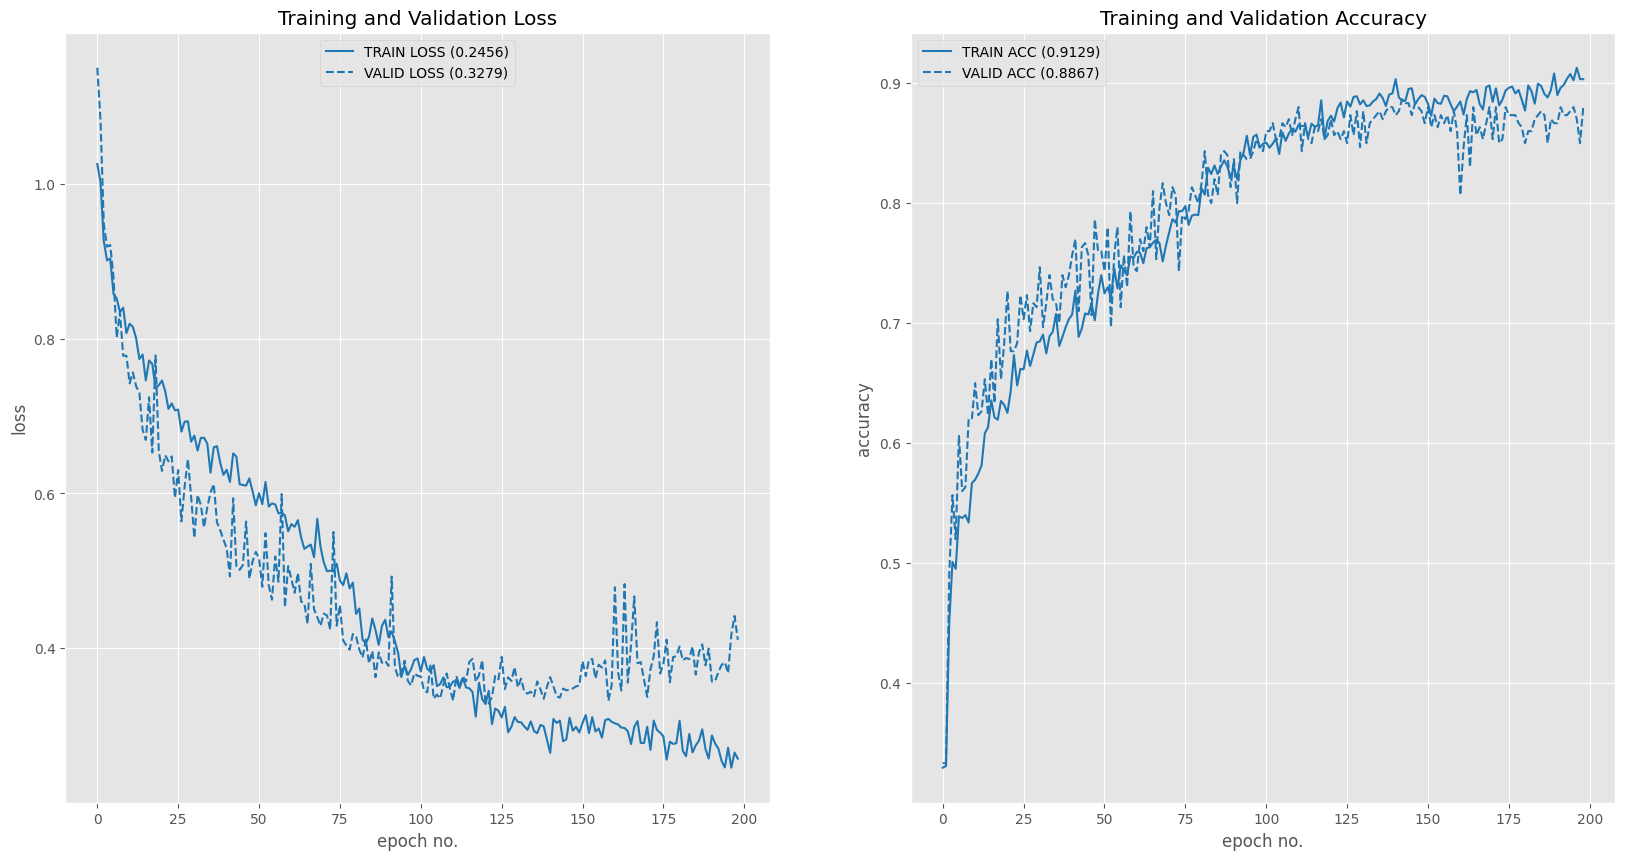

In [26]:
if not training_config.predict_only:
    plot_loss_accuracy(
        train_loss=[train_loss],
        val_loss=[val_loss],
        train_acc=[train_acc],
        val_acc=[val_acc],
        colors=["blue"],
        loss_legend_loc="upper center",
        acc_legend_loc="upper left",
    )

# <font style="color:blue">Step 5. Sample Prediction</font><a name="step5"></a>

Show some sample predictions.

## <font style="color:blue">5.1. Make Predictions</font>

In [27]:
def prediction(model, device, batch_input):
    data = batch_input.to(device)

    with torch.no_grad():
        output = model(data)

    # Score to probability using softmax.
    prob = F.softmax(output, dim=1)

    # Get the max probability.
    pred_prob = prob.data.max(dim=1)[0]

    # Get the index of the max probability.
    pred_index = prob.data.max(dim=1)[1]

    return pred_index.cpu().numpy(), pred_prob.cpu().numpy()

## <font style="color:blue">5.2. Get Predictions on a Batch</font>

In [28]:
def get_sample_prediction(model, data_root, img_size, mean, std):
    batch_size = 15

    if torch.cuda.is_available():
        device = "cuda"
        num_workers = 8
    else:
        device = "cpu"
        num_workers = 2

    # It is important to do model.eval() before prediction.
    model.eval()

    # Send model to cpu/cuda according to your system configuration.
    model.to(device)

    # Transformed data
    valid_dataset_trans = datasets.ImageFolder(root=data_root, transform=image_common_transforms(img_size, mean, std))

    # Original image dataset
    valid_dataset = datasets.ImageFolder(root=data_root, transform=image_preprocess_transforms(img_size))

    data_len = valid_dataset.__len__()

    interval = int(data_len / batch_size)

    imgs = []
    inputs = []
    targets = []
    for i in range(batch_size):
        index = i * interval
        trans_input, target = valid_dataset_trans.__getitem__(index)
        img, _ = valid_dataset.__getitem__(index)

        imgs.append(img)
        inputs.append(trans_input)
        targets.append(target)

    inputs = torch.stack(inputs)

    cls, prob = prediction(model, device, batch_input=inputs)

    plt.style.use("default")
    plt.rcParams["figure.figsize"] = (15, 9)
    fig = plt.figure()

    for i, target in enumerate(targets):
        plt.subplot(3, 5, i + 1)
        img = transforms.functional.to_pil_image(imgs[i])
        plt.imshow(img)
        plt.gca().set_title(f"P:{valid_dataset.classes[cls[i]]}({prob[i]:.2}), T:{valid_dataset.classes[targets[i]]}")
    plt.show()

    return

## <font style="color:blue">5.3. Load Model and Run Inference</font>

Next, we will reload the best saved model and use the `get_sample_prediction` function to make some sample predictions. This step is instrumental in visually assessing the performance of our model on the validation dataset, providing a quick and practical insight into how well our model generalizes to new, unseen data.


mean: tensor([0.4573, 0.4348, 0.3884]), std: tensor([0.2686, 0.2601, 0.2600])


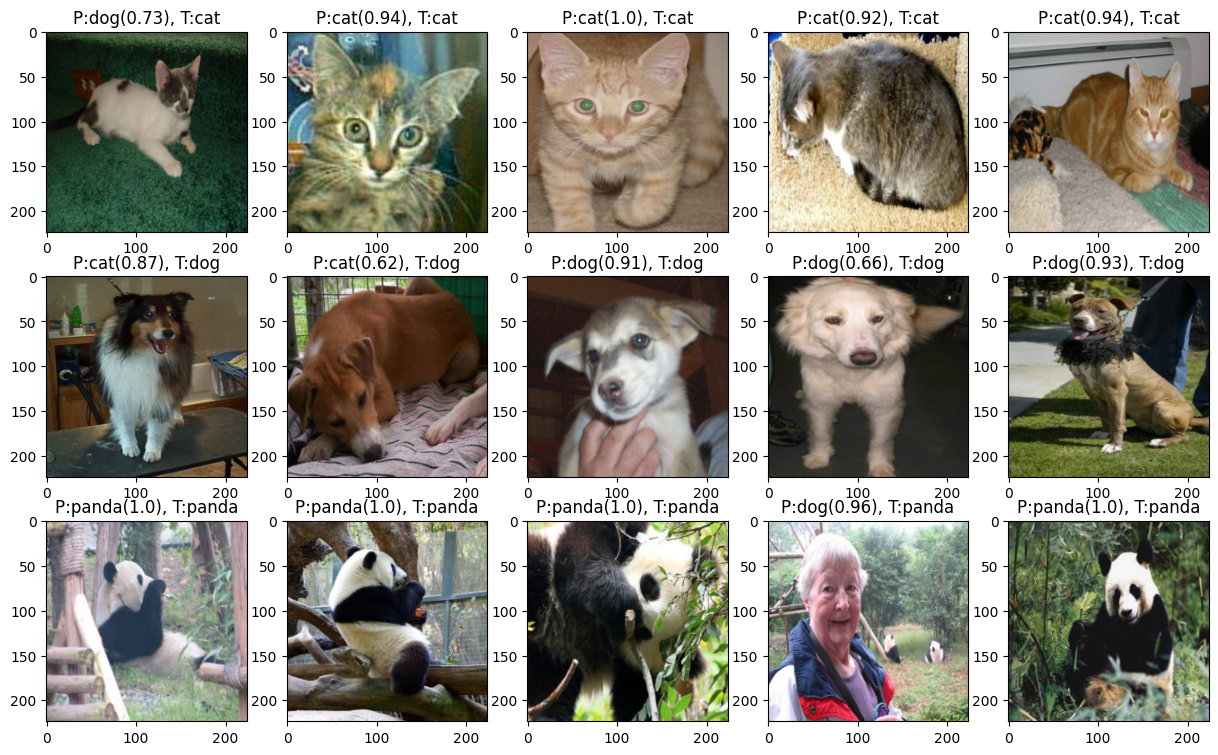

In [29]:
trained_model = MyModel()
trained_model = load_model(
    trained_model,
    model_dir=training_config.checkpoint_dir,
    model_file_name=training_config.save_model_name
)

train_data_path = os.path.join(training_config.data_root, "Train")
valid_data_path = os.path.join(training_config.data_root, "Valid")

if training_config.predict_only:
    mean = torch.tensor([0.4573, 0.4348, 0.3884])
    std = torch.tensor([0.2686, 0.2601, 0.2600])
else:
    mean, std = get_mean_std(train_data_path, img_size=training_config.img_size)

get_sample_prediction(trained_model, valid_data_path, img_size=training_config.img_size, mean=mean, std=std)

# <font style="color:red">Step 6. Display Confusion Matrix [5 Points]</font>

Display the confusion matrix (Refer to the earlier lectures on Performance Metrics for this).


This is what the output should look like:

<img src='https://www.dropbox.com/scl/fi/pgl21i5viwohke8hr4jm9/c3_w5_sample_confusion_matrix.jpg?rlkey=4c1vvwajedudrn5f99lwdpbi6&dl=1' width=600>



In [30]:
# YOUR CODE HERE

# first let us write a function to predict the class of entire dataset. Then we can draw confusion matrix and classification report.
def predict_dataset(model, data_root, img_size, mean, std, batch_size=32):
    if torch.cuda.is_available():
        device = "cuda"
        num_workers = 8
    else:
        device = "cpu"
        num_workers = 2

    # It is important to do model.eval() before prediction.
    model.eval()

    # Send model to cpu/cuda according to your system configuration.
    model.to(device)

    # Transformed data
    dataset_trans = datasets.ImageFolder(root=data_root, transform=image_common_transforms(img_size, mean, std))
    loader = DataLoader(dataset=dataset_trans, batch_size=batch_size, num_workers=num_workers, shuffle=False)
    all_preds = []
    all_targets = []
    for batch_data, batch_target in loader:
        preds, _ = prediction(model, device, batch_input=batch_data)
        all_preds.extend(preds)
        all_targets.extend(batch_target.numpy())

    return np.array(all_preds), np.array(all_targets)

def compute_classification_report(model, data_root, img_size, mean, std, batch_size=32):
    from sklearn.metrics import classification_report, confusion_matrix
    import seaborn as sns

    preds, targets = predict_dataset(model, data_root, img_size, mean, std, batch_size)

    print("Classification Report:\n")
    print(classification_report(targets, preds))

    cm = confusion_matrix(targets, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Cat', 'Dog', 'Panda'], yticklabels=['Cat', 'Dog', 'Panda'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()



/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.72      0.76       100
           1       0.71      0.82      0.76       100
           2       0.98      0.92      0.95       100

    accuracy                           0.82       300
   macro avg       0.83      0.82      0.82       300
weighted avg       0.83      0.82      0.82       300



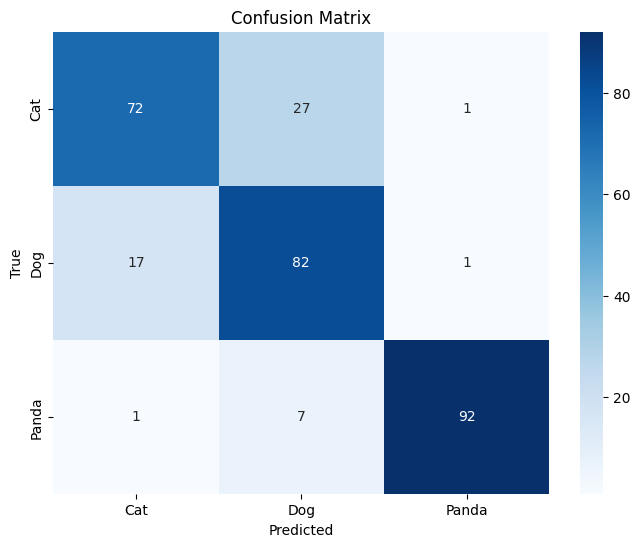

In [31]:
# REMOVED for LOCAL RUN
if not training_config.predict_only:
    compute_classification_report(trained_model, valid_data_path, img_size=training_config.img_size, mean=mean, std=std, batch_size=32)

# <font style="color:red">Step 7. Generate Submission File [10 Points]</font>


**TASK**

1. Generate predictions on the test set.
2. Create a submission `.csv` file.
3. Upload the `.csv` file on Kaggle.


**REFERENCE**
1. **`test.csv`** -  This CSV file contains image IDs for the test set. Read this CSV file to generate predictions for each test image.

2. **`sample_submission.csv`** - Refer to this file to understand the structure of the csv file to be submitted. The sample_submission file is only to be used as reference. <br>
It contains columns:
    1. **`ID`**: same as the test.csv file
    2. **`CLASS`**: which contains random predictions




**<font style="color:red">Use the same column names that are given in the`sample_submission.csv` file.</font>**


In [32]:
def run_inference_on_image(model, image_path, img_size, mean, std, class_mapping={0: 'cat', 1: 'dog', 2: 'panda'}):
    from PIL import Image

    # It is important to do model.eval() before prediction.
    model.eval()

    if torch.cuda.is_available():
        device = "cuda"
    else:
        device = "cpu"

    # Send model to cpu/cuda according to your system configuration.
    model.to(device)

    # Load and preprocess image
    img = Image.open(image_path).convert("RGB")
    preprocess = image_common_transforms(img_size, mean, std)
    input_tensor = preprocess(img).unsqueeze(0)  # Create a mini-batch
    input_tensor = input_tensor.to(device)
    cls, prob = prediction(model, device, batch_input=input_tensor)
    print(f"Predicted Class: {class_mapping[cls[0]]}, Probability: {prob[0]:.4f}")
    return cls, prob
# Example usage:
# image_path = "../data/animal-data/dataset/Valid/Cat/Cat_0001.jpg"
# run_inference_on_image(trained_model, image_path, img_size=training_config.img_size, mean=mean, std=std)

def run_inference_on_folder(model, folder_path, img_size, mean, std):
    from PIL import Image
    import glob

    # It is important to do model.eval() before prediction.
    model.eval()

    if torch.cuda.is_available():
        device = "cuda"
    else:
        device = "cpu"

    # Send model to cpu/cuda according to your system configuration.
    model.to(device)

    image_paths = glob.glob(os.path.join(folder_path, '*'))
    for image_path in image_paths:
        # Load and preprocess image
        img = Image.open(image_path).convert("RGB")
        preprocess = image_common_transforms(img_size, mean, std)
        input_tensor = preprocess(img).unsqueeze(0)  # Create a mini-batch
        input_tensor = input_tensor.to(device)
        cls, prob = prediction(model, device, batch_input=input_tensor)
        print(f"Image: {os.path.basename(image_path)} --> Predicted Class: {cls[0]}, Probability: {prob[0]:.4f}")
    return

In [33]:
import pandas as pd


### YOUR CODE HERE
test_data_path = os.path.join(os.path.abspath(training_config.data_root), "Test")

test_csv_path = os.path.join(training_config.data_root, "../", "test.csv")
if training_config.local_run:
    submission_csv_path = os.path.join(training_config.data_root, "../", "submission.csv")
else:
    submission_csv_path = os.path.join(training_config.checkpoint_dir, "submission.csv")
test_df = pd.read_csv(test_csv_path)
#create new dataframe with ID and Class columns
submission_df = pd.DataFrame(columns=['ID', 'CLASS'])

class_mapping = {0: 'cat', 1: 'dog', 2: 'panda'}

#run inference on each image that listed in test_df
for idx, row in test_df.iterrows():
    image_id = row['ID']
    image_path = os.path.join(test_data_path, image_id)
    cls, prob = run_inference_on_image(trained_model, image_path, img_size=training_config.img_size, mean=mean, std=std, class_mapping=class_mapping)
    #append to submission_df
    new_row = {'ID': image_id, 'CLASS': class_mapping[list(cls)[0]]}
    submission_df = pd.concat([submission_df, pd.DataFrame([new_row])], ignore_index=True)


#save submission_df to csv
submission_df.to_csv(submission_csv_path, index=False)
# #flush to disk
# submission_df.to_csv(submission_csv_path, index=False)


###

Predicted Class: cat, Probability: 0.8791
Predicted Class: dog, Probability: 0.5340
Predicted Class: panda, Probability: 0.9999
Predicted Class: panda, Probability: 1.0000
Predicted Class: cat, Probability: 0.9991
Predicted Class: dog, Probability: 0.9631
Predicted Class: dog, Probability: 0.6919
Predicted Class: panda, Probability: 1.0000
Predicted Class: cat, Probability: 0.8217
Predicted Class: panda, Probability: 0.9996
Predicted Class: dog, Probability: 0.9377
Predicted Class: panda, Probability: 1.0000
Predicted Class: cat, Probability: 0.9997
Predicted Class: cat, Probability: 0.9800
Predicted Class: dog, Probability: 0.9939
Predicted Class: dog, Probability: 0.9923
Predicted Class: panda, Probability: 1.0000
Predicted Class: dog, Probability: 0.7363
Predicted Class: dog, Probability: 0.9720
Predicted Class: cat, Probability: 0.9612
Predicted Class: panda, Probability: 0.8476
Predicted Class: panda, Probability: 0.9998
Predicted Class: cat, Probability: 0.8480
Predicted Class: c

## <font style="color:red">Step 8. Kaggle Submission Score [40 Points]</font>

**For full points, you need to achieve atleast `85%` accuracy on the Public Test leaderboard. If accuracy is less than `80%`, you gain no points for this section.**


**Submit `submission.csv` (prediction for images in `test.csv`), in the `Submit Predictions` tab in Kaggle, in order to get evaluated for this section.**

**Please share your profile link, user id and score achieved.**

```
URL: https://www.kaggle.com/ramabyg
Profile Name: RamaByg
Points Scored: 0.83833
```

**Upon completing the project, <font style="color:red">upload the notebook to the lab for grading and feedback.</font>**

**<font style="color:red">Please do not make your notebooks public or publish them on the competition page. You only need to submit your notebook to the lab. This is to make sure that students don't copy each other.</font>**